# 使用 Diffusion Map 和 PAGA 进行轨迹推断

本教程展示基于 Diffusion Map 和 PAGA 的胰腺内分泌发育轨迹分析流程。它强调的是一种非常常用的思路：先用 diffusion 几何刻画细胞在连续流形上的渐变关系，再用 PAGA 对整体分支拓扑做更清晰的抽象概括。

## 方法背景

参考 [Scanpy 的 diffusion pseudotime 文档](https://scanpy.readthedocs.io/en/latest/api/scanpy.tl.dpt.html)、[Scanpy 的 PAGA 轨迹教程](https://scanpy.readthedocs.io/en/1.10.x/tutorials/trajectories/paga-paul15.html) 以及原始 [PAGA 论文](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-019-1663-x)，这个工作流结合了两个互补的思想。

- Diffusion Map 根据邻接图上的随机游走结构来嵌入细胞，因此更强调状态之间的连续过渡。
- Diffusion Pseudotime (DPT) 在给定根部区域后，可以沿这个流形对细胞进行伪时间排序。
- PAGA（partition-based graph abstraction）则进一步把 cluster 之间的连接关系抽象成更容易解释的粗粒度拓扑图，比直接看致密的单细胞图更清楚。

因此，这套组合特别适合同时观察“连续变化的轨迹几何”和“cluster 层面的全局分支结构”。

## 为什么这里使用胰腺数据？

胰腺内分泌发育是 diffusion-based 轨迹推断的一个很合适的教学数据集。它既包含明显的 progenitor-to-endocrine 连续进展，也包含多个终末分支，因此很适合同时展示连续的 pseudotime 结构和 PAGA 抽象出的高层拓扑。

## 数据预处理

这里我们以胰腺发育数据为例，先进行轨迹推断，再用 PAGA 对整体拓扑进行概括。


In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
ov.plot_set(font_path='Arial')

%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
adata = ov.datasets.pancreatic_endocrinogenesis()

⚠️ File ./data/endocrinogenesis_day15.h5ad already exists
 Loading data from ./data/endocrinogenesis_day15.h5ad


✅ Successfully loaded: 3696 cells × 27998 genes


In [3]:
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=3000)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=50)

🔍 [2026-05-12 15:46:50] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 17750/27998 genes are kept.
    Among 17750 genes, 16426 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,696 cells × 16,426 genes
   ✓ Runtime: 0.11s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 3,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 3,000 highly variable genes out of 16,426 total (18.3%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.52 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.3075s                                                 │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3696x3000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=50
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3696, 3000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (7.87s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 7.8698s                                                 │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3696x50)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


我们先查看各个主成分对总方差的贡献。这一步可以帮助判断后续构建细胞邻接关系时需要使用多少个 PC。实际分析中，通常只需要一个大致合理的 PC 数即可。

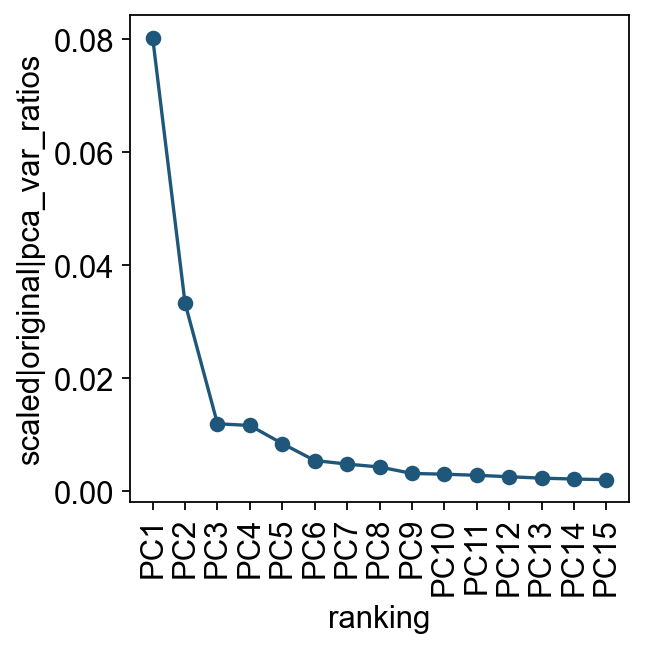

In [4]:
ov.utils.plot_pca_variance_ratio(adata, n_pcs=15)

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


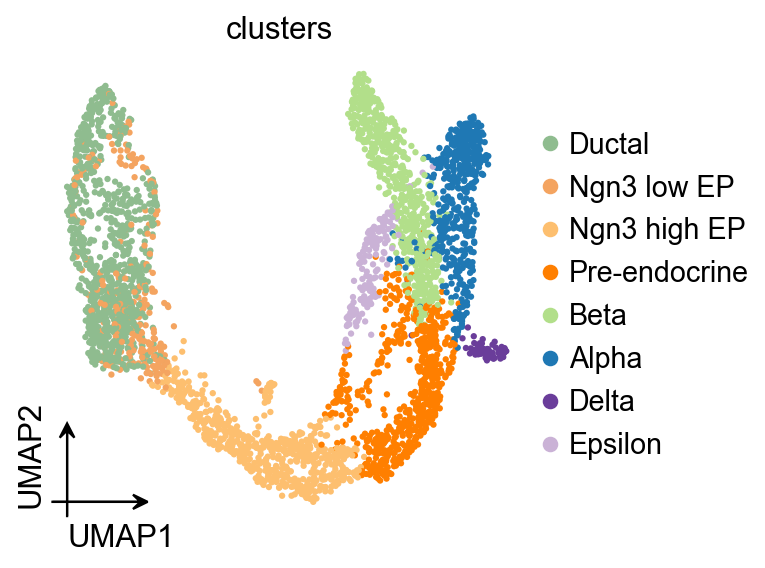

In [5]:
ov.pl.umap(
    adata,
    color='clusters'
)

## Diffusion Map

这里使用 `ov.single.TrajInfer` 构建轨迹推断对象。

In [6]:
Traj=ov.single.TrajInfer(
    adata,
    basis='X_umap',
    groupby='clusters',
    use_rep='scaled|original|X_pca',
    n_comps=50,
)
Traj.set_origin_cells('Ductal')

In [7]:
Traj.inference(method='diffusion_map')

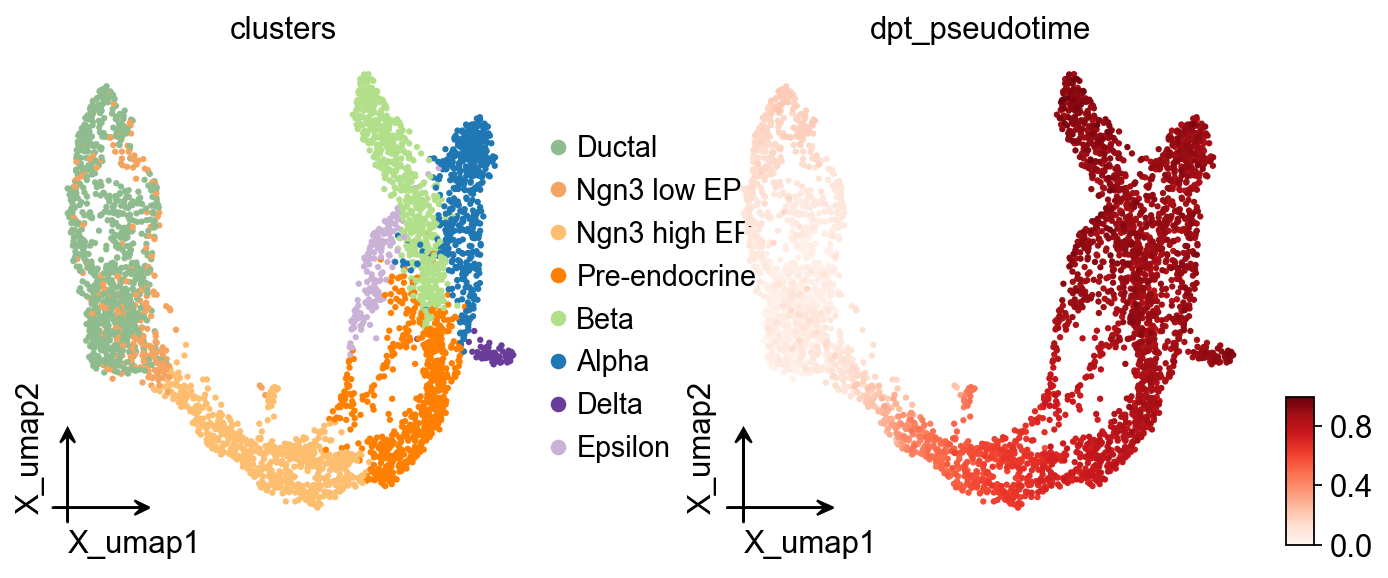

In [8]:
ov.pl.embedding(
    adata,
    basis='X_umap',
    color=['clusters','dpt_pseudotime'],
    frameon='small',
    cmap='Reds'
)

PAGA 会把数据拓扑概括成一个带权图，边的权重表示两个 cluster 之间的连通强度。

这里进一步结合邻居方向信息，让 PAGA 结果更适合解释发育方向。

In [9]:
ov.utils.cal_paga(
    adata,
    use_time_prior='dpt_pseudotime',
    vkey='paga',
    groups='clusters'
)

running PAGA using priors: ['dpt_pseudotime']
    finished
added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


<Axes: title={'center': 'PAGA DPT-graph'}>

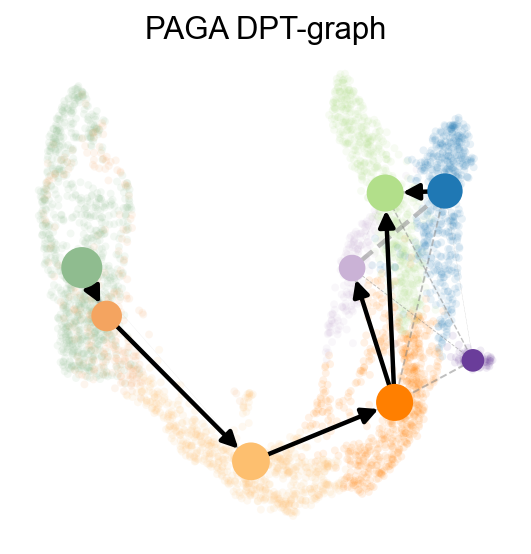

In [10]:
ov.utils.plot_paga(
    adata,basis='umap',
    size=50,
    alpha=.1,
    title='PAGA DPT-graph',
    min_edge_width=2,
    node_size_scale=1.5,
    show=False,
    legend_loc=False
)

## OV 轨迹图叠加

PAGA 图也可以通过统一的 `ov.pl.trajectory` 接口绘制，这样不同轨迹方法可以使用一致的可视化风格。

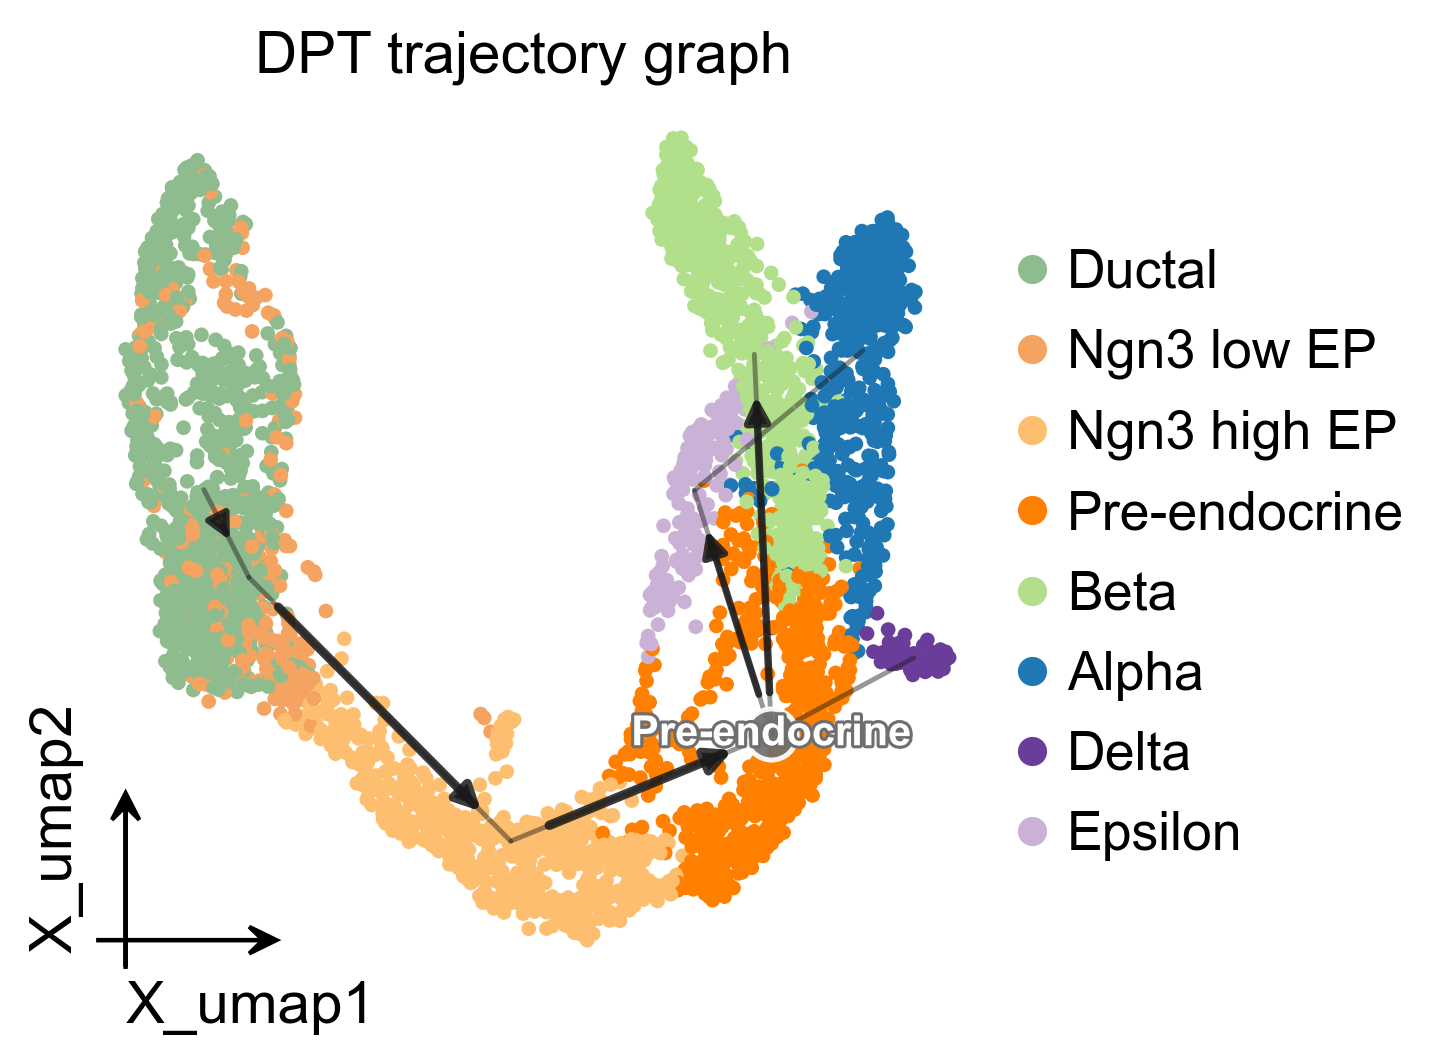

In [11]:
ov.pl.trajectory(
    adata,
    method='paga',
    basis='X_umap',
    groups='clusters',
    color='clusters',
    title='DPT trajectory graph',
)
plt.show()

## OV 轨迹图、投影和树状视图

`ov.pl.trajectory_graph`、`ov.pl.trajectory_projection` 和 `ov.pl.trajectory_tree` 会复用同一个 PAGA 结果，从而得到一致的图结构摘要、embedding 投影和伪时间树状视图。

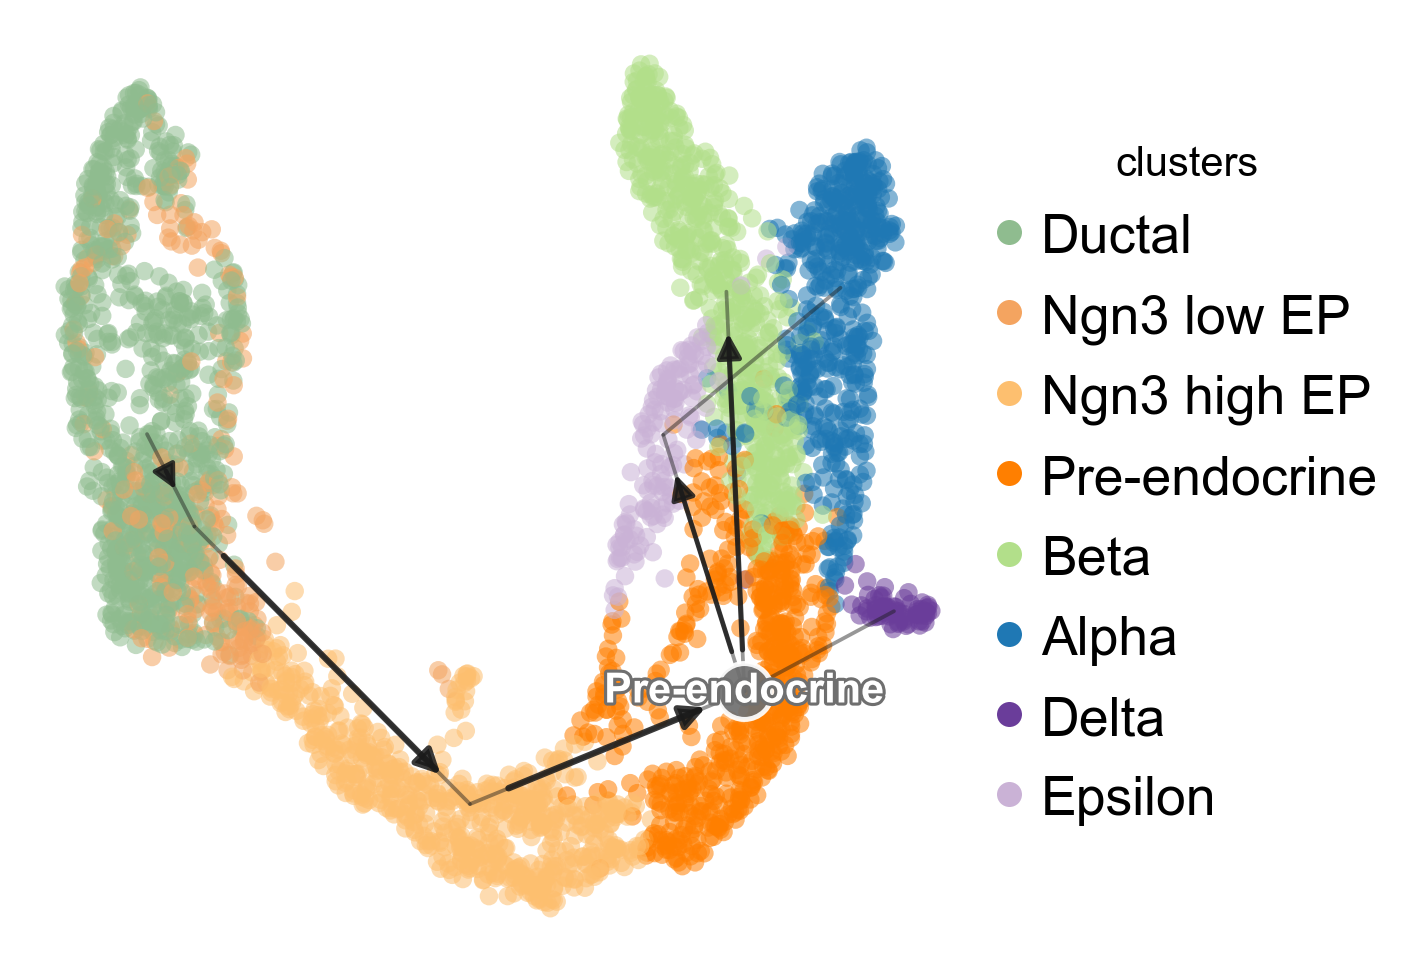

In [12]:
fig, ax = ov.pl.trajectory_graph(
    adata,
    method='paga',
    basis='X_umap',
    groups='clusters',
    color='clusters',
    figsize=(4, 4),
)
plt.show()

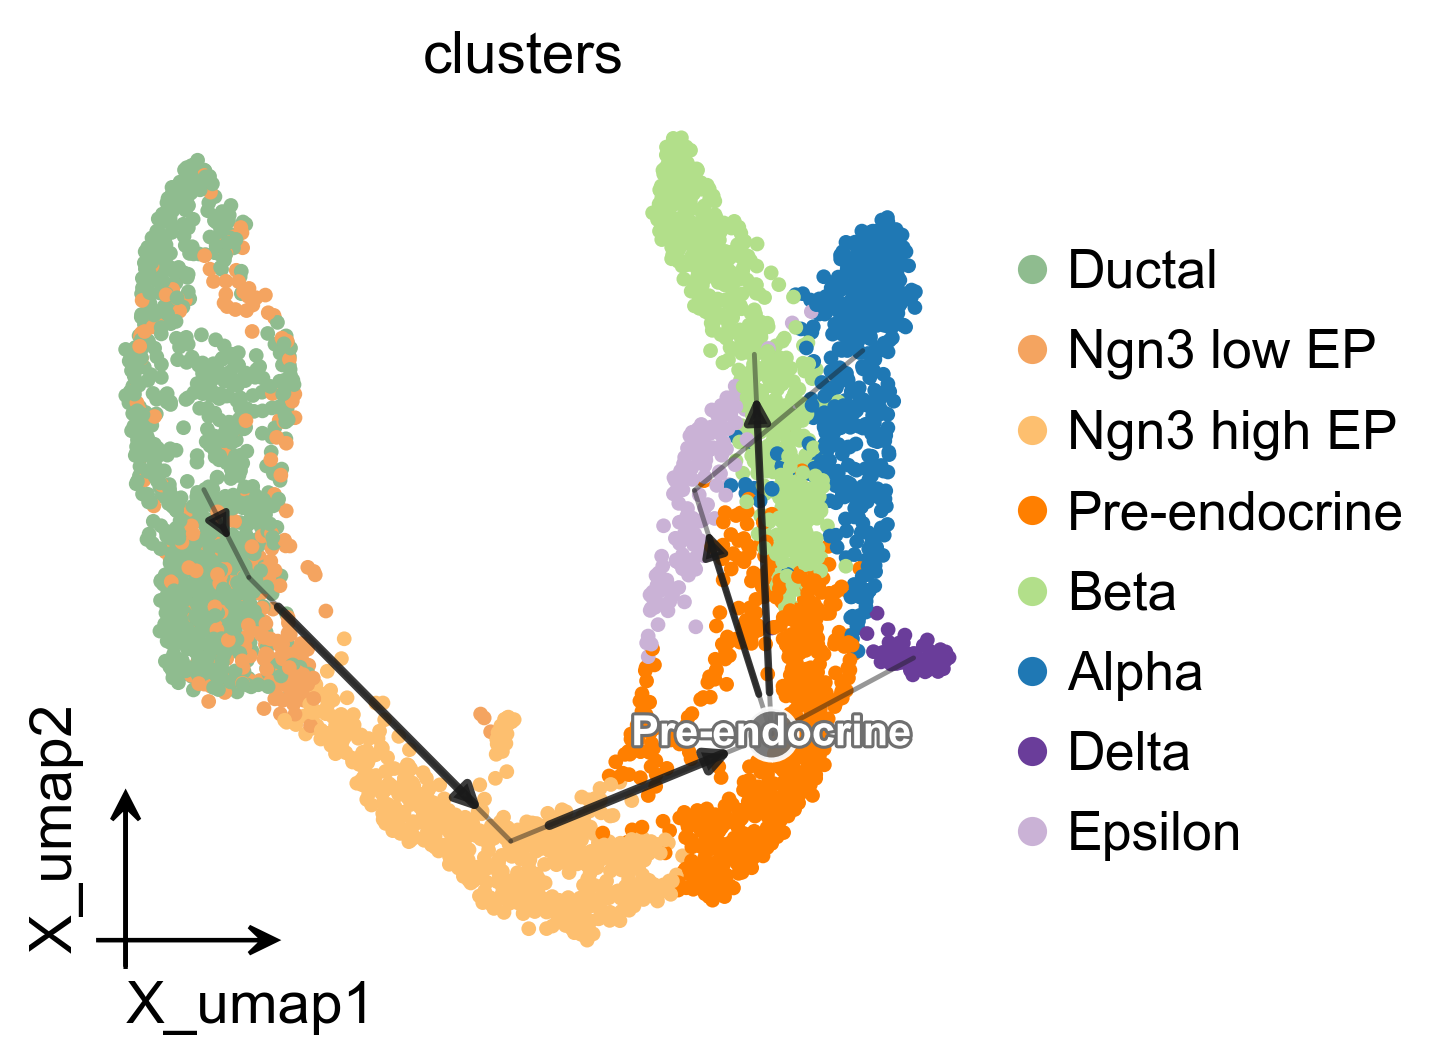

In [13]:
fig, ax = ov.pl.trajectory_projection(
    adata,
    method='paga',
    basis='X_umap',
    groups='clusters',
    color='clusters',
)
plt.show()

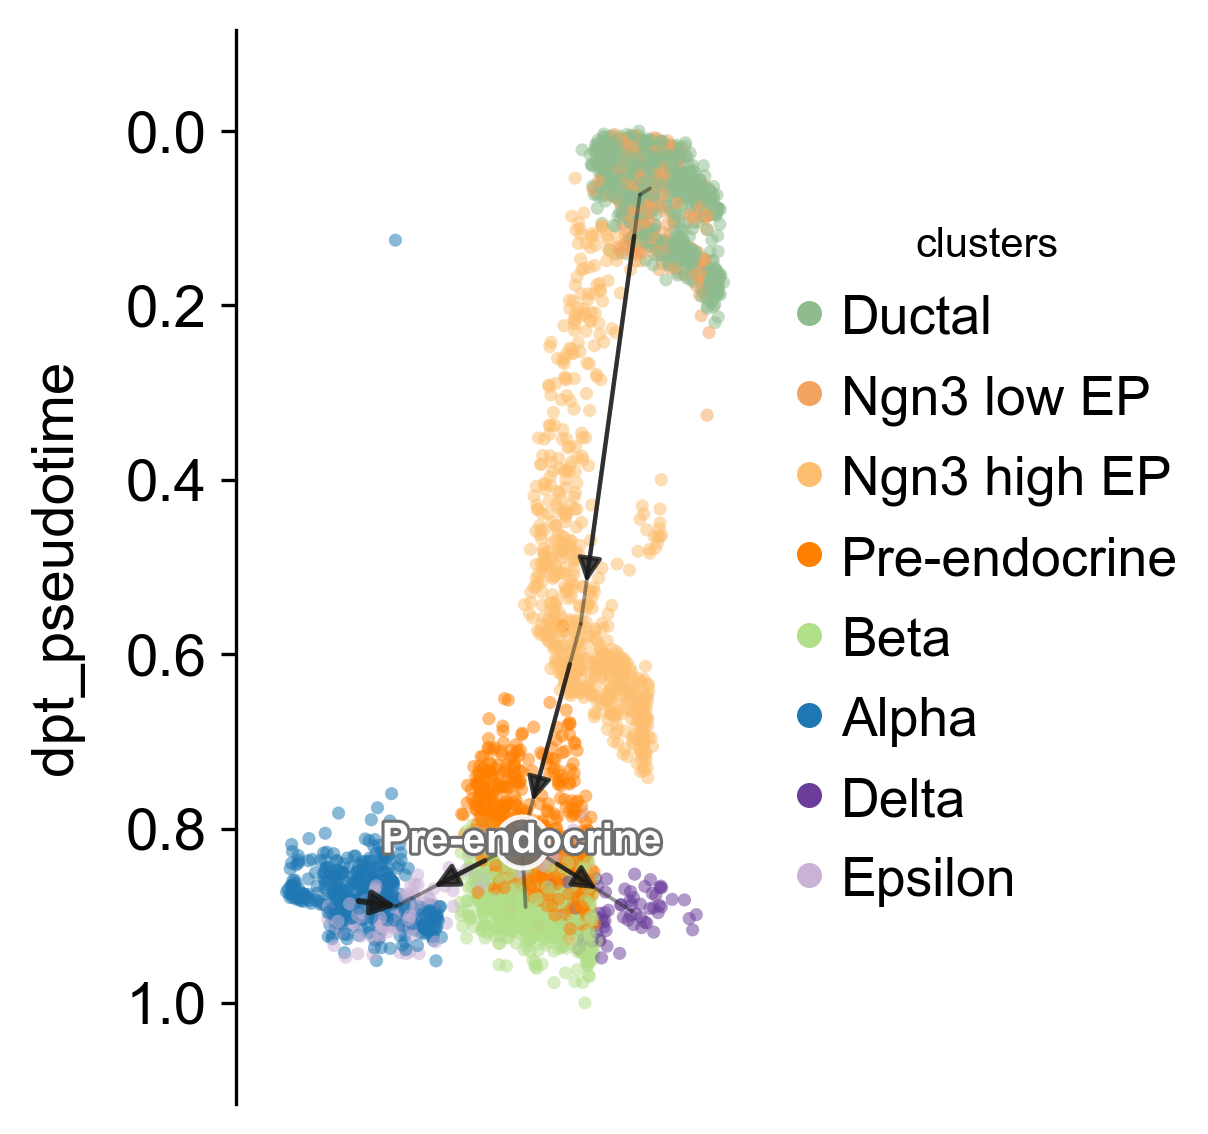

In [14]:
fig, ax = ov.pl.trajectory_tree(
    adata,
    method='paga',
    basis='X_umap',
    groups='clusters',
    pseudotime='dpt_pseudotime',
    color='clusters',
)
plt.show()

## OV 轨迹叠加

`ov.pl.trajectory_overlay` 可以把 PAGA 骨架叠加到已有 UMAP embedding 上。

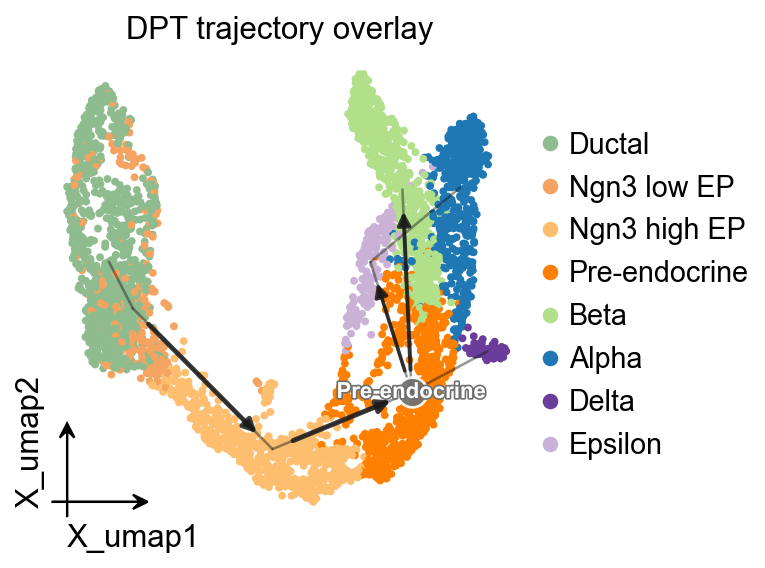

In [15]:
fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.embedding(
    adata,
    basis='X_umap',
    color='clusters',
    ax=ax,
    show=False,
    size=50,
)
ov.pl.trajectory_overlay(
    adata,
    ax=ax,
    method='paga',
    basis='X_umap',
    groups='clusters',
)
ax.set_title('DPT trajectory overlay')
plt.show()

## 分支感知的伪时间流图

`ov.pl.branch_streamplot` 只需要伪时间和细胞状态标签，因此也可以用于这个轨迹推断方法。图中 ribbon 的宽度表示某类细胞在伪时间上的富集位置，分叉的中心线则帮助观察不同 endocrine fate 在何处展开。


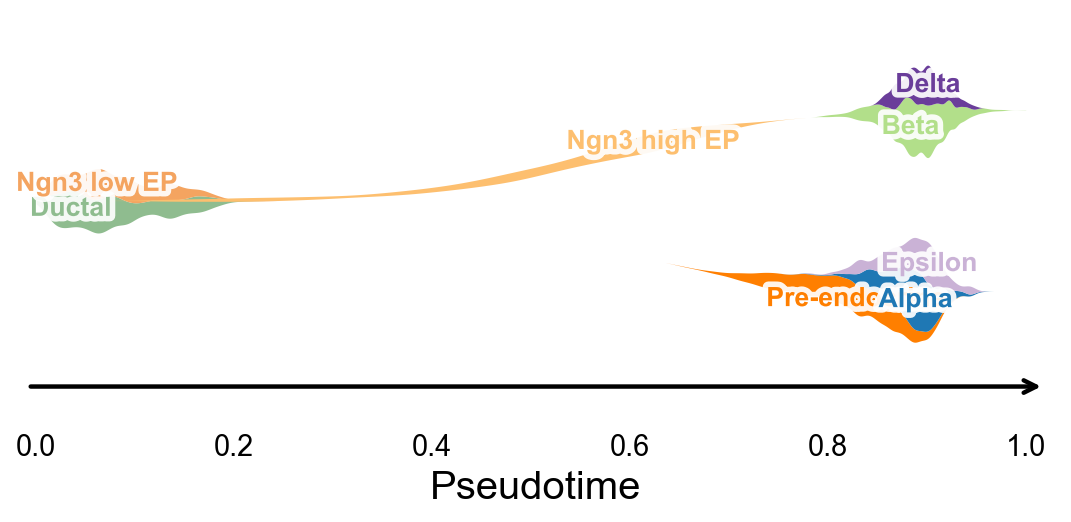

In [16]:
fig, ax = ov.pl.branch_streamplot(
    adata,
    group_key='clusters',
    pseudotime_key='dpt_pseudotime',
    show=False,
)
plt.show()

## Embedding stream plot

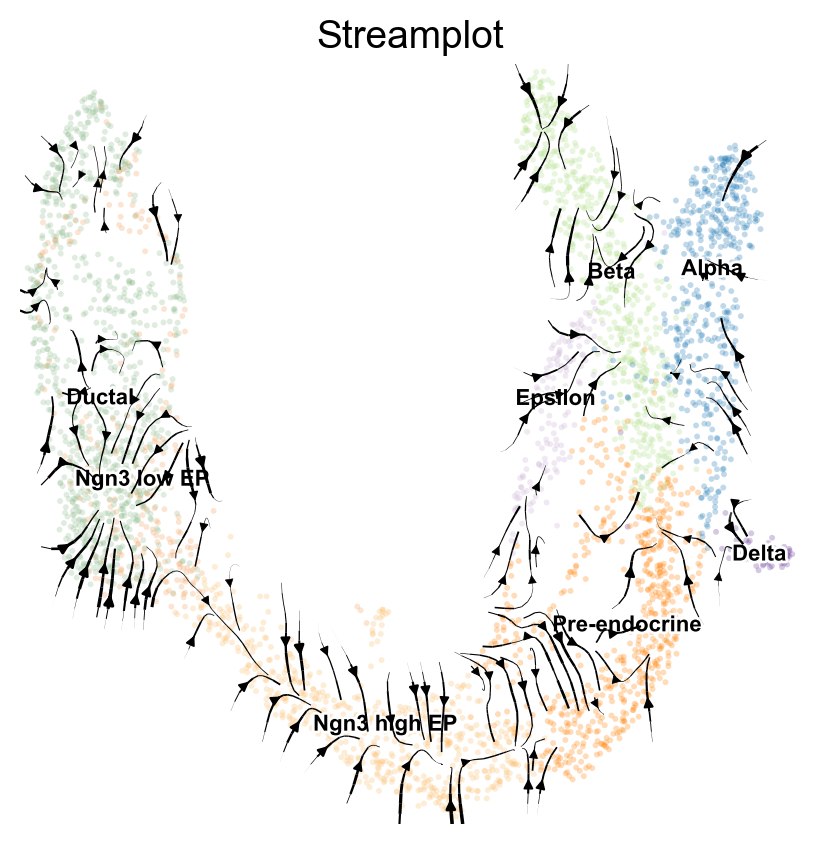

In [17]:
fig, ax = ov.pl.plot_stream(
    adata,
    method="pseudotime",
    figsize=(5, 5),
    dpi=100,
    basis="X_umap",
    pseudotime_key="dpt_pseudotime",
    color="clusters",
    density_grid=1.0,
    density_stream=2.5,
    scatter_size=18,
    scatter_alpha=0.28,
    linewidth=0.8,
    legend_loc="on data",
    legend_fontsize=8,
    legend_fontoutline=2,
    frameon=False,
    title="Streamplot",
)

## 使用 `dynamic_features` / `dynamic_trends` 分析 DPT 伪时间

`ov.single.dynamic_features` 可以沿 `dpt_pseudotime` 拟合 marker 趋势。这里我们先画一张全局 marker 趋势图，并用 cluster 给原始散点着色；然后再比较晚期 Alpha / Beta 分支，展示分支相关的表达变化。

In [18]:
import numpy as np

dpt_trend_genes = ['Sox9', 'Neurog3', 'Fev', 'Gcg', 'Arx', 'Pax4', 'Ins2', 'Pdx1', 'Sst', 'Hhex']

diffusion_dyn = ov.single.dynamic_features(
    adata,
    genes=dpt_trend_genes,
    pseudotime='dpt_pseudotime',
    use_raw=adata.raw is not None,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
    raw_obs_keys=['clusters'],
)


🔍 Dynamic feature analysis:
   Views: 1 | Features: 10
   Pseudotime: dpt_pseudotime
   Stored raw obs keys: ['clusters']
   Expression source: adata.raw
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/10 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 10/10
   ✓ Fitted rows: 2000
   ✓ Raw observations stored: 36960


### Single-line global trends

这张图为每个基因只拟合一条全局趋势线，同时用细胞注释给原始散点着色。它适合区分“整体伪时间表达趋势”和“哪些细胞状态贡献了这些散点”。




🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=False | compare_groups=False


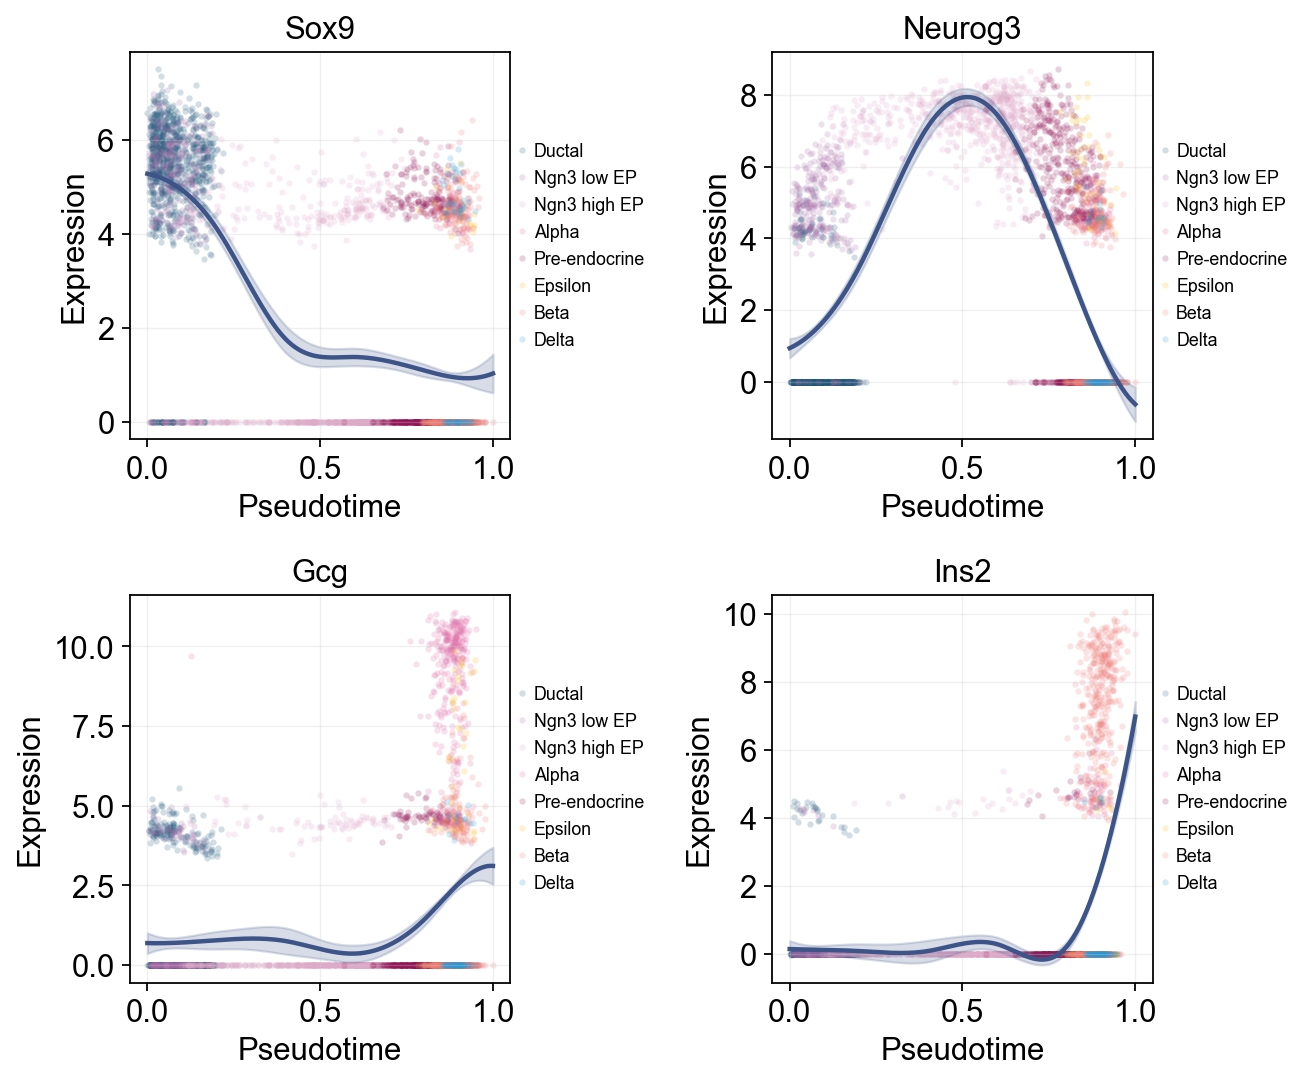

✅ Dynamic trend plotting completed!


In [19]:
ov.pl.dynamic_trends(
    diffusion_dyn,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    add_point=True,
    point_color_by='clusters',
    figsize=(5, 3.5),
    ncols=2,
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()

### 多标记基因趋势比较

这里把多个 marker 的拟合曲线叠加在同一伪时间坐标中，方便直接比较不同程序的启动和衰减顺序。



🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=True | compare_groups=False


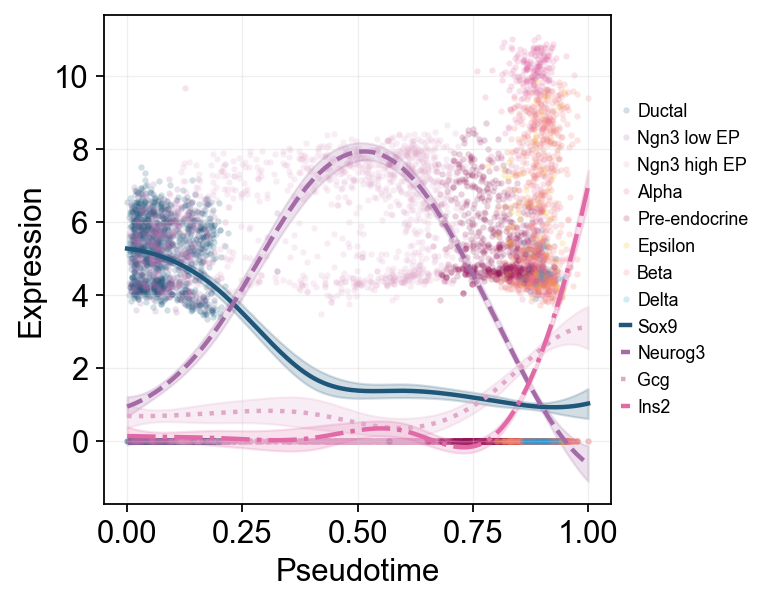

✅ Dynamic trend plotting completed!


In [20]:
ov.pl.dynamic_trends(
    diffusion_dyn,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    compare_features=True,
    add_point=True,
    point_color_by='clusters',
    line_style_by='features',
    figsize=(6, 4),
    linewidth=2,
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()

In [21]:
branch_clusters = ['Alpha', 'Beta']
split_mask = adata.obs['clusters'].astype(str).isin(['Ngn3 high EP', 'Pre-endocrine'])

diffusion_branch_dyn = ov.single.dynamic_features(
    adata,
    genes=['Gcg', 'Ins2', 'Pax4', 'Sox9'],
    pseudotime='dpt_pseudotime',
    groupby='clusters',
    groups=branch_clusters,
    use_raw=adata.raw is not None,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
)
split_time = float(np.nanmedian(adata.obs.loc[split_mask, 'dpt_pseudotime'])) if split_mask.any() else float(np.nanmedian(adata.obs['dpt_pseudotime']))


🔍 Dynamic feature analysis:
   Views: 2 | Features: 4
   Pseudotime: dpt_pseudotime
   Grouping: clusters
   Expression source: adata.raw
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 8/8
   ✓ Fitted rows: 1600
   ✓ Raw observations stored: 4288



🔍 Dynamic trend plotting:
   Features: 3 | Groups: 2
   compare_features=False | compare_groups=True


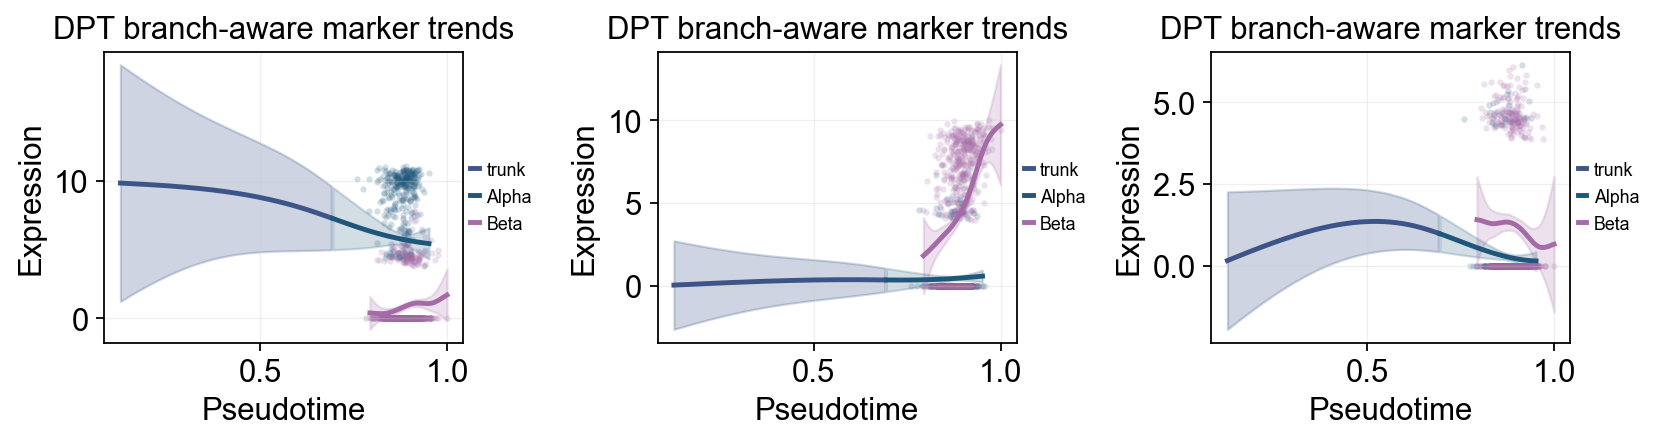

✅ Dynamic trend plotting completed!


In [22]:
ov.pl.dynamic_trends(
    diffusion_branch_dyn,
    genes=['Gcg', 'Ins2', 'Pax4'],
    compare_groups=True,
    split_time=split_time,
    shared_trunk=True,
    add_point=True,
    point_color_by='group',
    figsize=(4.2, 3),
    ncols=3,
    linewidth=2.2,
    legend_loc='right margin',
    legend_fontsize=8,
    title='DPT branch-aware marker trends',
)
plt.show()

## 使用 `dynamic_heatmap` 概括 DPT 标记基因程序

`ov.pl.dynamic_heatmap` 可以把多组基因压缩成一张按伪时间排序的热图。这里用它检查 progenitor 和 endocrine fate marker 是否沿 DPT 伪时间按 stream plot 所提示的顺序启动。



🔍 Dynamic heatmap:


   Candidate features: 10
   Pseudotime: dpt_pseudotime
   Cell annotation: clusters
   use_fitted=True | cell_bins=180 | cmap=RdBu_r



✅ Dynamic heatmap completed!
   ✓ Matrix shape: 10 features × 171 columns


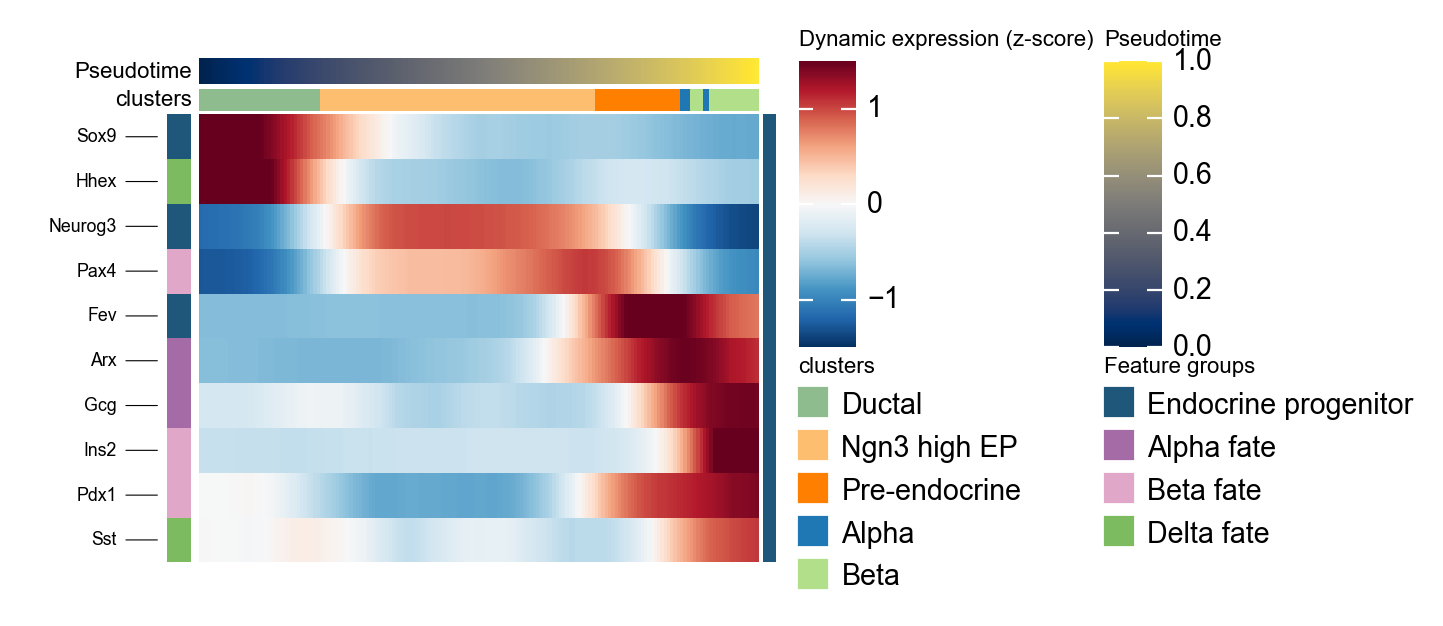

In [23]:
dpt_marker = {
    'Endocrine progenitor': ['Sox9', 'Neurog3', 'Fev'],
    'Alpha fate': ['Gcg', 'Arx'],
    'Beta fate': ['Pax4', 'Ins2', 'Pdx1'],
    'Delta fate': ['Sst', 'Hhex'],
}

g = ov.pl.dynamic_heatmap(
    adata,
    var_names=dpt_marker,
    pseudotime='dpt_pseudotime',
    use_raw=adata.raw is not None,
    use_cell_columns=False,
    cell_annotation='clusters',
    cell_bins=180,
    smooth_window=17,
    fitted_window=31,
    figsize=(5, 4),
    standard_scale='var',
    cmap='RdBu_r',
    use_fitted=True,
    border=False,
    show=False,
)